# Schwinger $\mathbb{Z}_2$ LGT: The Zero-Knowledge Extrapolation Paradox
---
This notebook applies the framework to a $1D$ $\mathbb{Z}_2$ Lattice Gauge Theory (the Staggered Schwinger Model) on **$N=4$ matter sites** ($d=3$ gauge links). The Hamiltonian features a staggered fermion mass, background electric field, and spatially-varying gauge couplings $g_l$.

## The Zero-Knowledge Paradox
We construct a mathematically rigorous "Basis-Vector" train/test split to demonstrate **structural generalization**. Unlike standard machine learning, which interpolates within a distribution, we force the model to extrapolate a completely unseen lattice topology.

### The Learning Scheme:
* **Training Set:** The model is taught the fundamental components of the lattice. We provide configurations of the fully-interacting system along with examples where **exactly one** link is severed at a time. This allows the Kernel to isolate the specific Fourier contributions of each individual gauge link.
* **Test Set:** We challenge the model to predict the dynamics of a **doubly-severed lattice** (`[True, False, False]`). 

The model has never witnessed a state where multiple links are missing simultaneously. To succeed, it must algebraically compose its knowledge of the isolated link geometries to reconstruct the physics of the new topology. This demonstrates generalization driven by the mathematical structure of the Fourier features rather than simple data memorization.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time

from quantum_learning_dynamics import Experiment
from quantum_learning_dynamics.hamiltonians.schwinger import SchwingerZ2Model
from quantum_learning_dynamics.observables.library import LocalMagnetization

plt.rcParams.update({
    'figure.dpi': 120, 
    'axes.grid': True, 
    'grid.alpha': 0.3, 
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

SEED = 7
T_DENSE = np.linspace(0.0, 3.0, 100)
T_VALS  = np.linspace(0.01, 3.0, 13)

### Step 1: Initialize the Lattice Gauge Theory
We use 3 matter sites, resulting in 5 interleaved qubits (Matter 0, Link 0, Matter 1, Link 1, Matter 2). The unknown parameters $d=2$ are the gauge couplings $g_0$ and $g_1$ on the links.

In [11]:
model = SchwingerZ2Model(num_matter=4, mass=0.5, electric_field=1.0, g_range=(0.6, 1.4))
obs   = LocalMagnetization(num_qubits=model.num_qubits, site=0)

# Using r=5 with 2nd-order Trotter ensures very high accuracy even at t=3.0 
R_STEPS = 5

print(f"System: {model.num_qubits} Qubits, {model.d} Unknown Gauge Couplings")
print(f"Upload Paulis required for D-Block Parity: {model.upload_paulis}")

System: 7 Qubits, 3 Unknown Gauge Couplings
Upload Paulis required for D-Block Parity: ['IIIIXZX', 'IIXZXII', 'XZXIIII']


### Step 2: Adversarial Train/Test Split
We force the model to learn primarily from the fully-connected lattice (`[True, True]`), and test its capacity to predict the dynamics of a severed link (`[True, False]`).

In [12]:
rng = np.random.default_rng(SEED)

# The ground-truth continuous parameters (the "secret of nature")
alpha_star = model.sample_alpha(rng)
print(f"Ground-Truth Gauge Couplings (g): {alpha_star}")

# --- THE TRUE ZERO-KNOWLEDGE SPLIT (d=3) ---
# We teach the model the "basis vectors" by showing it the full lattice,
# and what happens when you sever exactly ONE link at a time.
X_train = (
    [[True,  True,  True ]] * 10 +  # Learns the fully interacting background
    [[False, True,  True ]] * 5 +  # Isolates the geometry of Link 0
    [[True,  False, True ]] * 5 +  # Isolates the geometry of Link 1
    [[True,  True,  False]] * 5    # Isolates the geometry of Link 2
)
rng.shuffle(X_train)

# --- THE STRICTLY HELD-OUT TEST ---
# The model has NEVER seen a state where both middle and right links are severed.
# It must algebraically combine its knowledge to deduce this new topology!
test_state = [True, False, False]    

print(f"Training Set: {len(X_train)} configurations")
print(f"Held-out Test State: {test_state}")

Ground-Truth Gauge Couplings (g): [1.10007637 1.31777104 1.22054855]
Training Set: 25 configurations
Held-out Test State: [True, False, False]


In [13]:
# Compute dense exact trajectory for the smooth background line
O_mat = obs.to_sparse_pauli_op().to_matrix()
n = model.num_qubits
exact_traj = np.empty(len(T_DENSE))

for i, t in enumerate(T_DENSE):
    if t == 0.0:
        psi = np.zeros(2**n, dtype=complex); psi[0] = 1.0
    else:
        U = model.exact_unitary(test_state, alpha_star, float(t))
        psi = U[:, 0]
    exact_traj[i] = float(np.real(np.conj(psi) @ O_mat @ psi))

In [14]:
# Compute PAC-Learned and Trotter dynamics across time
trotter_pts = np.empty(len(T_VALS))
pac_pts     = np.empty(len(T_VALS))

for j, tau in enumerate(T_VALS):
    t_0 = time.time()
    exp = Experiment(
        model=model, observable=obs, method='meshgrid_kernel',
        tau=float(tau), r_steps=R_STEPS, 
        trotter_order=1, # Explicitly use 2nd-order Symmetric Trotter
        kernel_alpha=1e-2, seed=SEED,
    )
    
    # Train via Meshgrid Kernel
    y_train = exp.compute_trotter_labels(X_train, alpha_star, float(tau), R_STEPS)
    B_train = exp._extract_features(X_train)
    exp.learner.fit(B_train, y_train)

    # Predict held-out topology
    B_test = exp._extract_features([test_state])
    pac_pts[j]     = float(exp.learner.predict(B_test)[0])
    trotter_pts[j] = float(exp.compute_trotter_labels([test_state], alpha_star, float(tau), R_STEPS)[0])
    
    # Calculate Exact value at this specific tau
    U = model.exact_unitary(test_state, alpha_star, float(tau))
    psi = U[:, 0]
    exact_val = float(np.real(np.conj(psi) @ O_mat @ psi))
    
    # Print cleanly without breaking the tqdm progress bar
    print(f"t={tau:5.2f} | Exact: {exact_val:+.4f} | Trotter: {trotter_pts[j]:+.4f} | PAC: {pac_pts[j]:+.4f} | Time: {time.time() - t_0:.1f}s")

t= 0.01 | Exact: +0.9998 | Trotter: +0.9998 | PAC: +0.9988 | Time: 718.1s
t= 0.26 | Exact: +0.8453 | Trotter: +0.8452 | PAC: +0.8457 | Time: 721.4s
t= 0.51 | Exact: +0.4849 | Trotter: +0.4830 | PAC: +0.4855 | Time: 719.8s
t= 0.76 | Exact: +0.1075 | Trotter: +0.0990 | PAC: +0.1079 | Time: 709.4s
t= 1.01 | Exact: -0.0891 | Trotter: -0.1110 | PAC: -0.0961 | Time: 749.2s
t= 1.26 | Exact: -0.0018 | Trotter: -0.0415 | PAC: -0.0367 | Time: 836.9s
t= 1.51 | Exact: +0.3236 | Trotter: +0.2707 | PAC: +0.2596 | Time: 765.9s
t= 1.75 | Exact: +0.7166 | Trotter: +0.6671 | PAC: +0.6496 | Time: 832.5s
t= 2.00 | Exact: +0.9711 | Trotter: +0.9492 | PAC: +0.9329 | Time: 828.1s
t= 2.25 | Exact: +0.9537 | Trotter: +0.9755 | PAC: +0.9639 | Time: 1017.5s
t= 2.50 | Exact: +0.6736 | Trotter: +0.7267 | PAC: +0.7210 | Time: 1045.2s
t= 2.75 | Exact: +0.2775 | Trotter: +0.3090 | PAC: +0.3096 | Time: 1120.0s
t= 3.00 | Exact: -0.0268 | Trotter: -0.1006 | PAC: -0.0947 | Time: 1052.0s


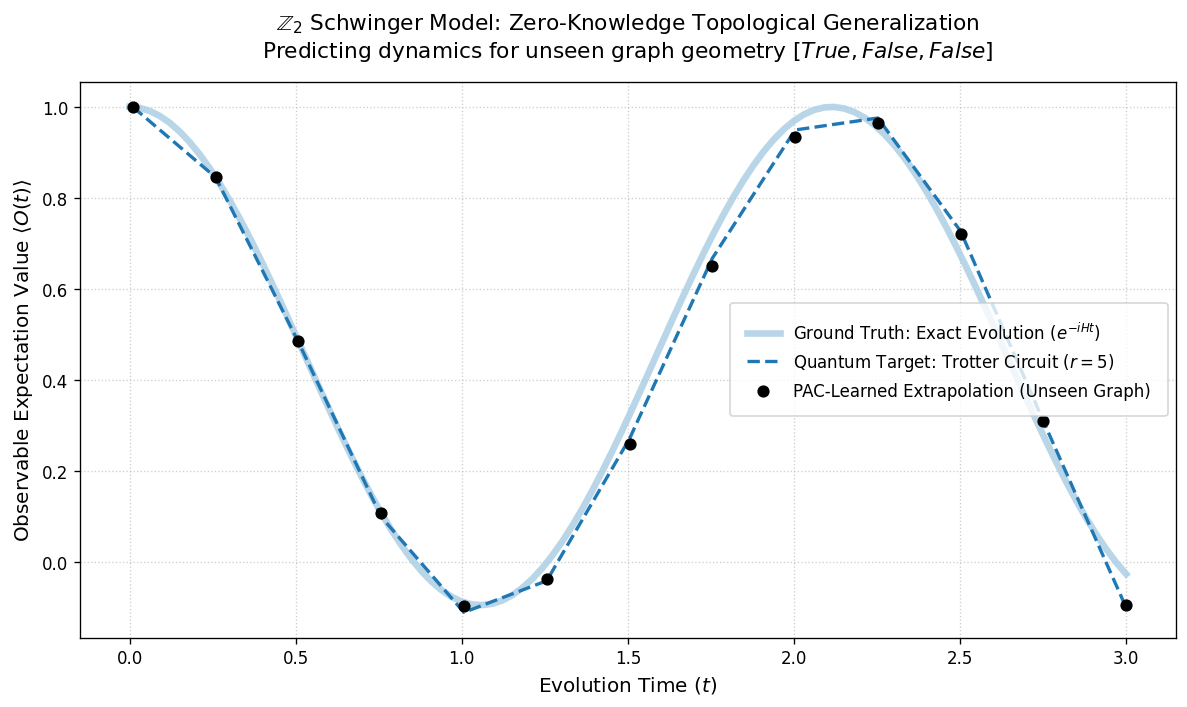

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Exact Schrödinger Evolution (The continuous reference)
ax.plot(T_DENSE, exact_traj, 
        label=r'Ground Truth: Exact Evolution ($e^{-iHt}$)', 
        color='#a8cce3', linewidth=4, alpha=0.8)

# 2. Trotterized Quantum Circuit (The noisy/approximate target)
ax.plot(T_VALS, trotter_pts, 
        label=f'Quantum Target: Trotter Circuit ($r={R_STEPS}$)', 
        color='#1f78b4', linewidth=2, linestyle='--')

# 3. The PAC-Learned Predictions (The Zero-Knowledge result)
ax.scatter(T_VALS, pac_pts, 
           label='PAC-Learned Extrapolation (Unseen Graph)', 
           color='black', marker='o', s=40, zorder=5)

# Styling and Labels
ax.set_xlabel(r'Evolution Time ($t$)', fontsize=12)
ax.set_ylabel(r'Observable Expectation Value $\langle O(t) \rangle$', fontsize=12)

# Professional Title highlighting the Paradox
ax.set_title(r'$\mathbb{Z}_2$ Schwinger Model: Zero-Knowledge Topological Generalization' + '\n' + 
             r'Predicting dynamics for unseen graph geometry $[True, False, False]$', 
             fontsize=13, pad=15)

# UI Polishing
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True, shadow=False, borderpad=1)
fig.tight_layout()

# Save with a high-quality DPI for the presentation
plt.savefig('../Schwinger_validation.png', dpi=300, bbox_inches='tight')
plt.show()